In [75]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import date, datetime, timedelta
from scipy.optimize import minimize

In [77]:
tickers = ["SPY", "QQQ", "VTI", "IXUS", "IBIT"]
start_date = "2025-01-01" # lookback date
data = yf.download(tickers, start=start_date, end=date.today(), interval="1h")["Close"]

  data = yf.download(tickers, start=start_date, end=date.today(), interval="1h")["Close"]
[*********************100%***********************]  5 of 5 completed


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.54it/s]


Stat                 s1
-------------------  ----------
Start                2025-01-01
End                  2025-11-21
Risk-free rate       0.00%

Total Return         10.18%
Daily Sharpe         0.63
Daily Sortino        1.06
CAGR                 11.54%
Max Drawdown         -18.99%
Calmar Ratio         0.61

MTD                  -7.88%
3m                   -2.41%
6m                   4.99%
YTD                  10.18%
1Y                   -
3Y (ann.)            -
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  11.54%

Daily Sharpe         0.63
Daily Sortino        1.06
Daily Mean (ann.)    13.00%
Daily Vol (ann.)     20.60%
Daily Skew           0.85
Daily Kurt           10.47
Best Day             8.97%
Worst Day            -4.61%

Monthly Sharpe       0.55
Monthly Sortino      0.94
Monthly Mean (ann.)  9.28%
Monthly Vol (ann.)   16.77%
Monthly Skew         -0.58
Monthly Kurt         -0.53
Best Month           7.67%
Worst Month          -7.88%

Yearly Sharpe        -

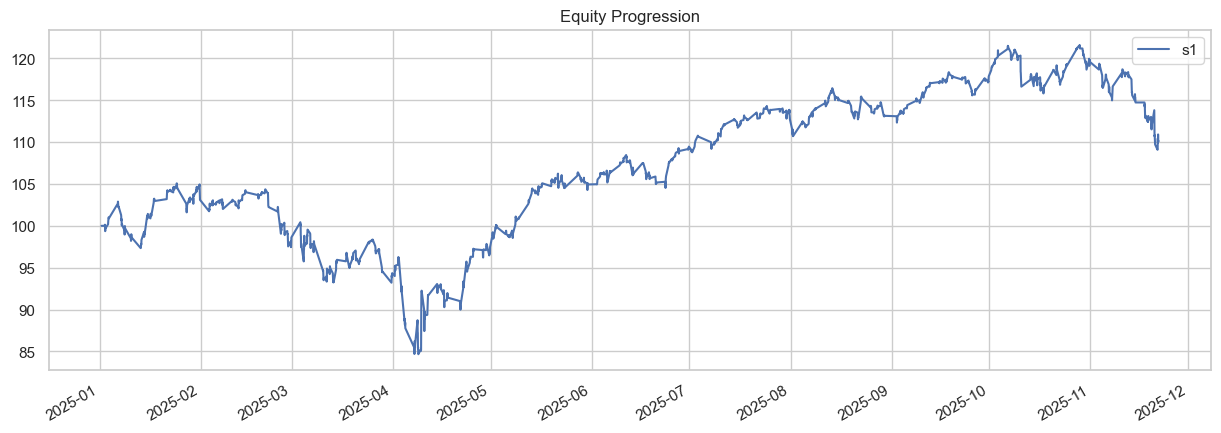

In [78]:
s = bt.Strategy('s1', [bt.algos.RunWeekly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighSpecified(SPY = .20, QQQ = .20, VTI = .20, IXUS = .20, IBIT = .20), # equal weights
                       bt.algos.Rebalance(),])

test2 = bt.Backtest(s, data)
res = bt.run(test2)
res.plot()
res.display()

In [79]:
tickers = ['spy', 'qqq', 'vti', 'ixus', 'ibit']

bt_data = bt.get('SPY, QQQ, VTI, IXUS, IBIT', start = start_date, end = date.today())
n = len(bt_data)
split_index = int(n * 0.6)  # first 40% to drop; keep last 60%
split_date = bt_data.index[split_index]
test_data = bt.get('SPY, QQQ, VTI, IXUS, IBIT', start = split_date, end = date.today())
train_data = bt.get('SPY, QQQ, VTI, IXUS, IBIT', start = start_date, end = split_date)
train_data.index = pd.to_datetime(train_data.index)
train_data = train_data.reset_index().rename(columns={'index': 'Date'})
test_data.index = pd.to_datetime(test_data.index)
test_data = test_data.reset_index().rename(columns={'index': 'Date'})

for ticker in tickers:
    y_train = train_data[ticker].dropna()

    # handle too-short series safely
    if len(y_train) < 20:
        print(f"Skipping {ticker} (not enough history)")
        continue

    # Fit ARIMA(1,1,1)
    model = SARIMAX(
        y_train,
        order=(0,1,1),
        enforce_invertibility=False,
        enforce_stationarity=False
    )

    results = model.fit(disp=False)

    # Forecast for the length of the test set
    steps = len(test_data)
    fc = results.forecast(steps=steps)

    # Store forecast column in test dataset
    test_data[f"{ticker}_forecast"] = fc.values

print("Forecast columns added successfully.")

Forecast columns added successfully.


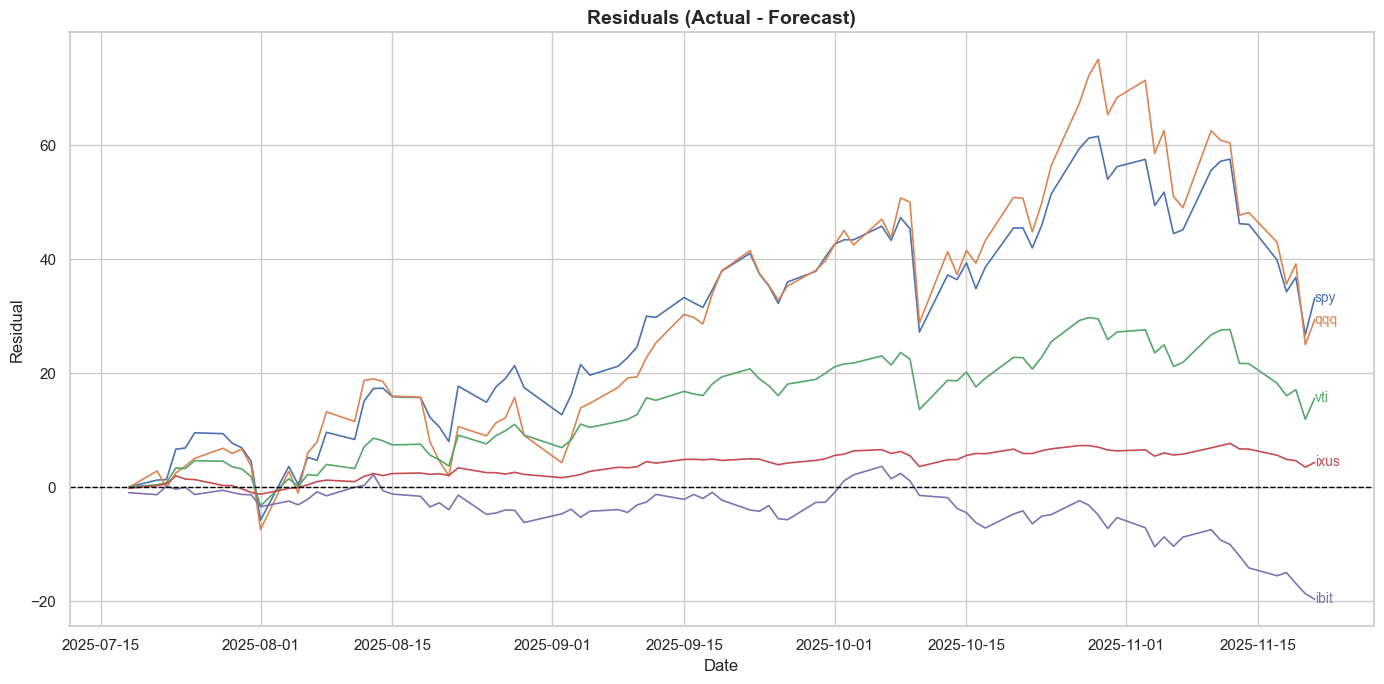

In [80]:
sns.set(style="whitegrid")

# --- Plot each ticker train/test split ---

plt.figure(figsize=(14, 7))

for ticker in tickers:
    forecast_col = f"{ticker}_forecast"
    if forecast_col not in test_data.columns:
        continue  # skip tickers without forecasts

    # Compute residuals
    residuals = test_data[ticker] - test_data[forecast_col]

    # Plot residuals
    line_res, = plt.plot(
        test_data["Date"], residuals,
        linewidth=1.2
    )

    # Extract the line color
    color = line_res.get_color()

    # Add label at the end of the line
    plt.text(
        test_data["Date"].iloc[-1],
        residuals.iloc[-1],
        f"{ticker}",
        fontsize=10,
        color=color,
        va='center'
    )

# Horizontal zero line
plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.title("Residuals (Actual - Forecast)", fontsize=14, weight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Residual", fontsize=12)

plt.tight_layout()
plt.show()

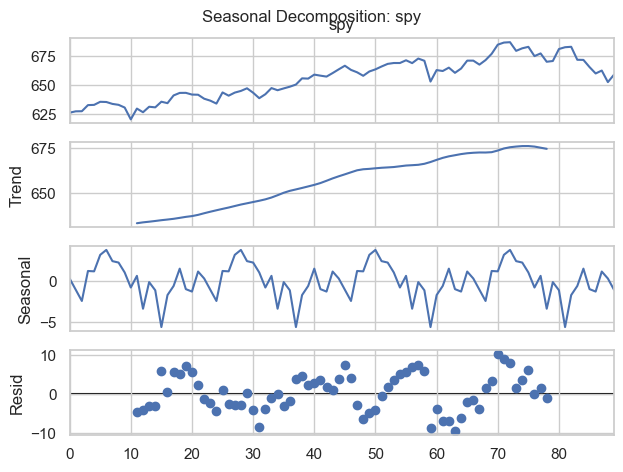

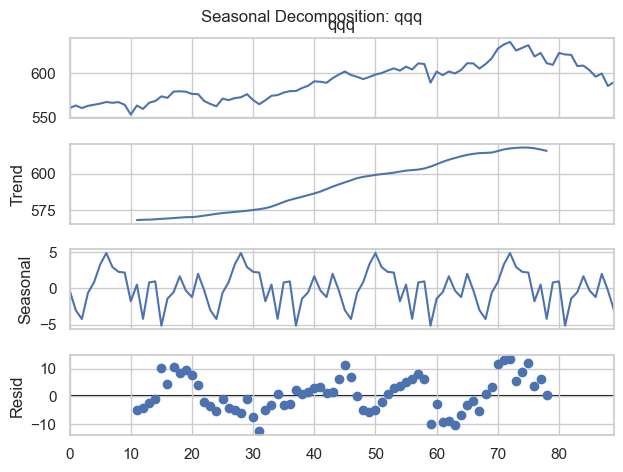

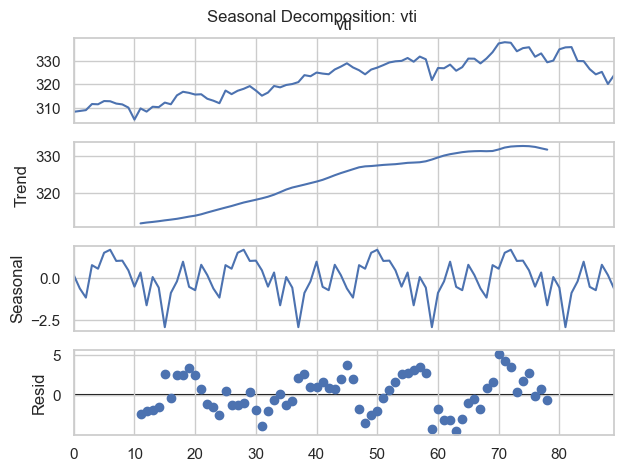

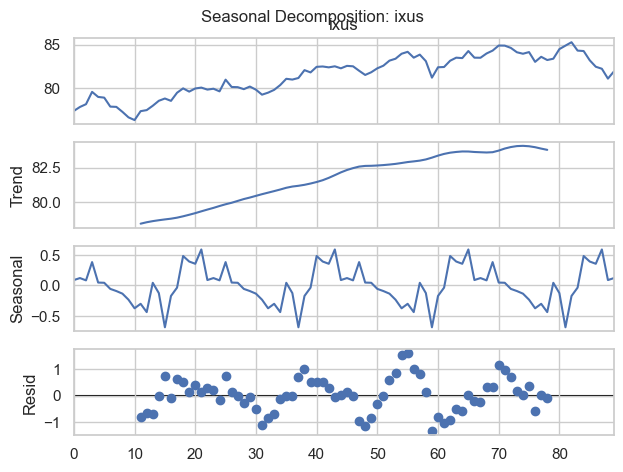

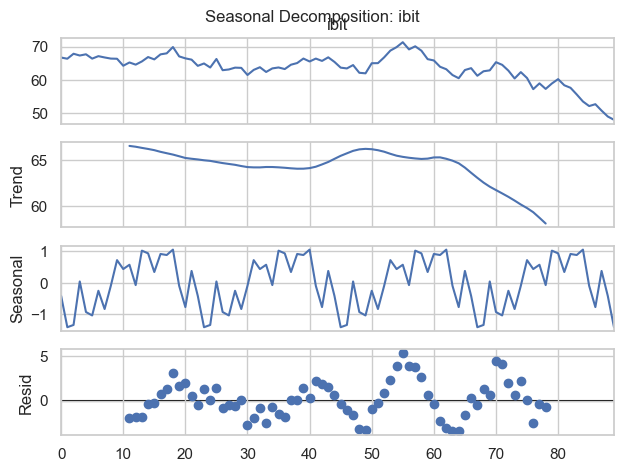

In [82]:
x = int(len(test_data) / 4)
def dec(df, *tickers, model='additive', period=(x), plot=True):
 
    decompositions = {}

    for ticker in tickers:
        decomposition = seasonal_decompose(df[ticker].dropna(), model=model, period=period)
        decompositions[ticker] = decomposition
        if plot:
            decomposition.plot()
            plt.suptitle(f"Seasonal Decomposition: {ticker}", fontsize=12)
            plt.show()

    return decompositions

decomps = dec(test_data, 'spy', 'qqq', 'vti', 'ixus', 'ibit')